## This notebook presents the result analysis and visualization for submission NCOMMS-26-018997-T

**Title:** *Impacts and Benefits of Electrified Space Heating on Renewable-Based Power Systems*

This notebook contains the analysis of simulation results and the corresponding visualizations prepared for the above submission.

Extended Data Figure 2; Supplementary Figure 6 - 8: Comparison of electricity demand with uncontrolled and controlled HP demands across
different HP deployment scenarios on a typical day.

**Contact:** Yi Guo  
**Email:** yi.guo@bit.edu.cn

C:\Users\Administrator\AppData\Local\Temp\ipykernel_52616\3381103162.py:71: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_time, end=end_time, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_52616\3381103162.py:135: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start=datetime(year, 1, 1), periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_52616\3381103162.py:135: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start=datetime(year, 1, 1), periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_52616\3381103162.py:135: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start=datetime(year, 1, 1), periods=8760, freq='H')
C:

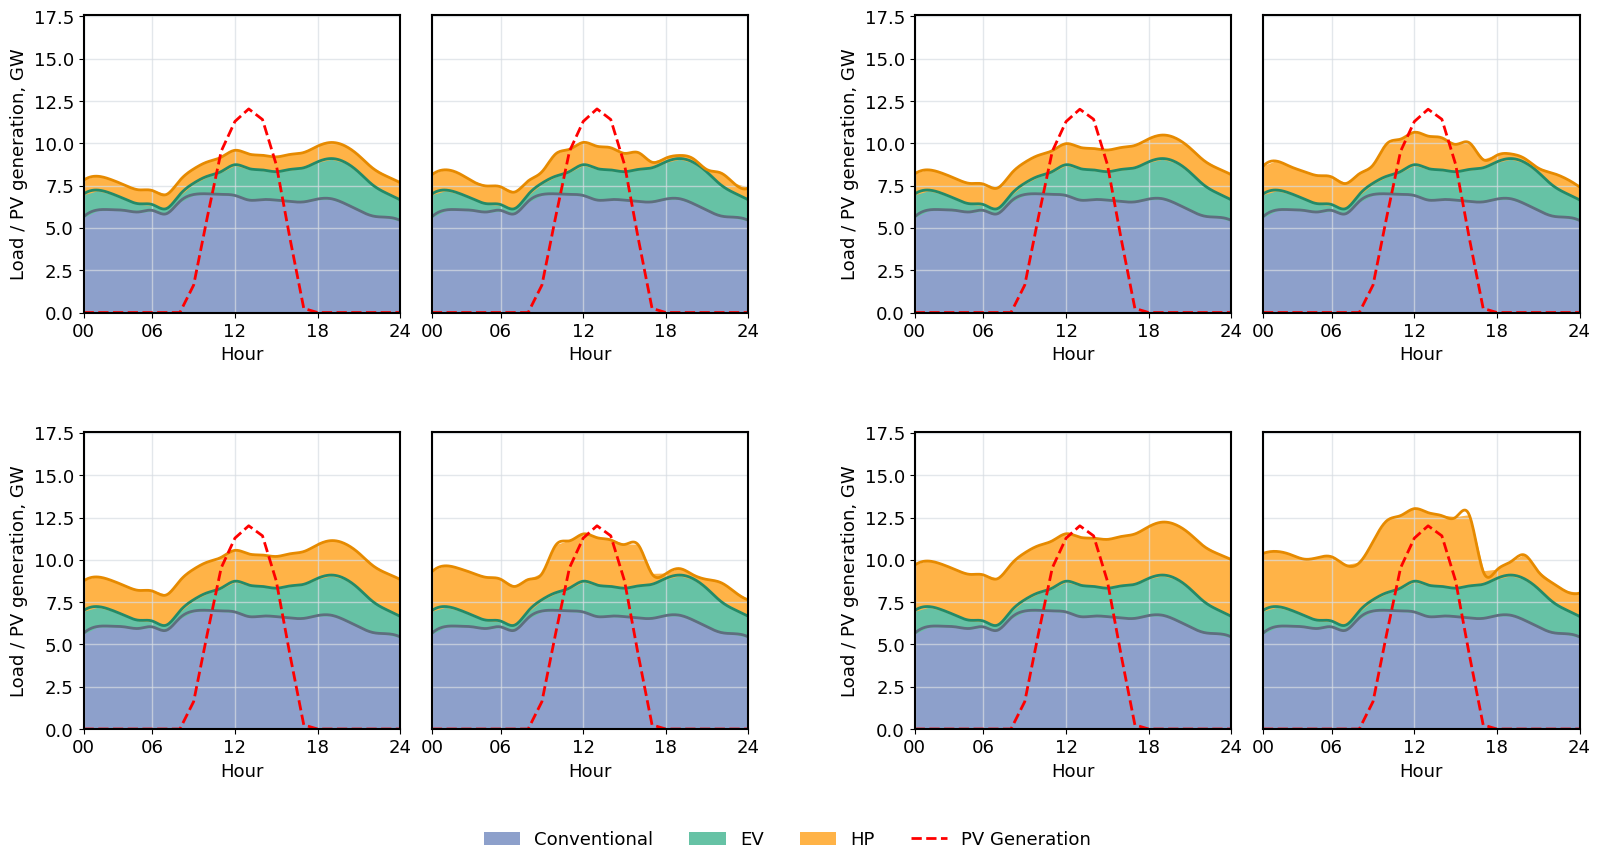

In [1]:
# ===========================================================================================================
# This cell analyses and visualizes the results as shown in Extended Data Fig.2 and Supplementary Fig.6 - Fig. 8
# ===========================================================================================================

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.interpolate import make_interp_spline
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib as mpl
from pathlib import Path
import os

# ========= Adjustable spacing parameters =========
OUTER_WSPACE = 0.25   # Horizontal spacing between outer left/right panels
OUTER_HSPACE = 0.4    # Vertical spacing between outer upper/lower panels
INNER_WSPACE = 0.1   # Horizontal spacing between the two subplots within each panel

# ========= Shared parameters =========
cases = ["case1a", "case1b", "case1c", "case1d"]
year = 2050
days_to_plot = 1

# ========= selection on a typical day =========
# # Typical winter day
start_month = 1
start_day = 15

# # Typical spring day
# start_month = 4
# start_day = 15

# # Typical summer day
# start_month = 8
# start_day = 15

# Typical autumn day
# start_month = 10
# start_day = 15

# ========= Morandi-style global font, line, and grid settings =========
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.linewidth": 1.5,
    "grid.linewidth": 1,
    "lines.linewidth": 1.5,
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.labelcolor": "black",
})

# ========= Colors =========
fill_colors = {"conventional": '#8DA0CB', "ev": '#66C2A5', "hp": '#FFB347'}
line_colors = {"conventional": '#5E6E7E', "ev": '#238A68', "hp": '#E68A00'}
pv_line_kwargs = dict(color='red', linestyle='--', linewidth=2.0)

use_hp_hatch = False

# ========= Time index and smoothing =========
start_time = datetime(year, start_month, start_day)
end_time = start_time + timedelta(hours=24 * days_to_plot - 1)
time_index = pd.date_range(start=start_time, end=end_time, freq='H')
x_vals = np.arange(len(time_index))
x_smooth = np.linspace(x_vals.min(), x_vals.max(), 300)
sm_x = pd.date_range(start=start_time, end=end_time, periods=300)

# === Generate five evenly spaced ticks (fixed at the start and end of the data range), labeled 00/06/12/18/24 ===
n_ticks = 5
_tick_idx = np.linspace(0, len(time_index) - 1, n_ticks)
_tick_idx[0] = 0
_tick_idx[-1] = len(time_index) - 1
xtick_positions = [time_index[int(i)] for i in _tick_idx]
xtick_labels = ["00", "06", "12", "18", "24"]

# ========= Create the canvas and 2×2 panel layout (with spacing passed during creation) =========
fig = plt.figure(figsize=(16, 8.5))
outer = fig.add_gridspec(2, 2, wspace=OUTER_WSPACE, hspace=OUTER_HSPACE)
fig.patch.set_facecolor('white')

global_ymax = 0.0

# ========= Plot each case as a paired-subplot panel =========
for i, case in enumerate(cases):
    r, c = divmod(i, 2)
    inner = outer[r, c].subgridspec(1, 2, wspace=INNER_WSPACE)  # Pass inner spacing directly when creating the subgridspec

    # 左/右子图
    ax1 = fig.add_subplot(inner[0, 0])
    ax2 = fig.add_subplot(inner[0, 1], sharey=ax1)

    for ax in (ax1, ax2):
        ax.set_facecolor('white')
        ax.set_xlim(time_index[0], time_index[-1])
        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels)
        ax.grid(True, which='major', axis='both', color='#D8DDE3', alpha=0.7)
        ax.grid(False, which='minor')
        ax.minorticks_off()

    try:
        # === Load data (left subplot: HP = unshifted eHeatPump) ===
        file_hp1 = fr"..\Output_data\power systems results\{case}\national_generation_and_capacity\0-demand_hourly_c_ch_{year}.csv"
        file_hp1 = os.path.abspath(file_hp1)
        df_hp1 = pd.read_csv(file_hp1)
        hp_series_1 = df_hp1["idProfile_eHeatPump"]

        # === Load data (right subplot: HP = aggregated AfterShift load) ===
        file_hp2 = fr"..\Output_data\power systems results\{case}\CentIv_{year}\0-LoadHeatPump_AfterShift_hourly_ALL_LP.csv"
        file_hp2 = os.path.abspath(file_hp2)
        df_hp2 = pd.read_csv(file_hp2, header=[0, 1, 2])
        df_hp2 = df_hp2.dropna(how="all").drop(columns=df_hp2.columns[0])
        df_hp2 = df_hp2.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        hp_series_2 = df_hp2.sum(axis=1)

        file_conv = fr"..\Output_data\power systems results\{case}\national_generation_and_capacity\0-demand_hourly_c_ch_{year}.csv"
        file_conv = os.path.abspath(file_conv)
        df_conv = pd.read_csv(file_conv)
  

        file_pv = fr"..\Output_data\power systems results\{case}\national_generation_and_capacity\0-national_generation_hourly_gwh_c_ch_{year}.csv"
        file_pv = os.path.abspath(file_pv)
        df_pv = pd.read_csv(file_pv)


        # Standardize the time index
        index = pd.date_range(start=datetime(year, 1, 1), periods=8760, freq='H')
        hp_series_1.index = hp_series_2.index = df_conv.index = df_pv.index = index

        # Unit conversion
        hp_series_1 /= 1000; hp_series_2 /= 1000
        df_conv = df_conv[["idProfile", "idProfile_eMobility"]] / 1000
        df_conv.columns = ["conventional", "emobility"]
        pv_series = df_pv["PV Alpine"] + df_pv["PV Roof"]

        # Select the target date window
        conv = df_conv.loc[start_time:end_time, "conventional"].values
        ev   = df_conv.loc[start_time:end_time, "emobility"].values
        hp1  = hp_series_1.loc[start_time:end_time].values
        hp2  = hp_series_2.loc[start_time:end_time].values
        pv   = pv_series.loc[start_time:end_time]

        # Left subplot
        conv_cumsum = conv
        ev_cumsum = conv_cumsum + ev
        hp_cumsum1 = ev_cumsum + hp1

        ax1.fill_between(time_index, 0, conv_cumsum, color=fill_colors["conventional"])
        ax1.fill_between(time_index, conv_cumsum, ev_cumsum, color=fill_colors["ev"])
        ax1.fill_between(time_index, ev_cumsum, hp_cumsum1, color=fill_colors["hp"])
        for y_vals, clr in zip([conv_cumsum, ev_cumsum, hp_cumsum1],
                               [line_colors["conventional"], line_colors["ev"], line_colors["hp"]]):
            spl = make_interp_spline(x_vals, y_vals, k=3)
            ax1.plot(sm_x, spl(x_smooth), color=clr, linewidth=2.0)

        ax1.plot(pv.index, pv.values, **pv_line_kwargs)
        ax1.set_xlabel("Hour")
        ax1.set_ylabel("Load / PV generation, GW")

        # Right subplot
        hp_cumsum2 = ev_cumsum + hp2
        ax2.fill_between(time_index, 0, conv_cumsum, color=fill_colors["conventional"])
        ax2.fill_between(time_index, conv_cumsum, ev_cumsum, color=fill_colors["ev"])
        ax2.fill_between(time_index, ev_cumsum, hp_cumsum2, color=fill_colors["hp"])
        for y_vals, clr in zip([conv_cumsum, ev_cumsum, hp_cumsum2],
                               [line_colors["conventional"], line_colors["ev"], line_colors["hp"]]):
            spl = make_interp_spline(x_vals, y_vals, k=3)
            ax2.plot(sm_x, spl(x_smooth), color=clr, linewidth=2.0)

        ax2.plot(pv.index, pv.values, **pv_line_kwargs)
        ax2.set_xlabel("Hour")
        ax2.tick_params(axis='y', left=False, labelleft=False)

        local_max = np.nanmax([hp_cumsum1.max(), hp_cumsum2.max()])
        if np.isfinite(local_max): global_ymax = max(global_ymax, float(local_max))

    except Exception as e:
        ax1.text(0.5, 0.5, f"{case}\nData not found", ha='center', va='center',
                 transform=ax1.transAxes, fontsize=12, color="#5E6E7E")
        ax2.text(0.5, 0.5, f"{case}\nData not found", ha='center', va='center',
                 transform=ax2.transAxes, fontsize=12, color="#5E6E7E")

# Set a shared y-axis upper limit
if global_ymax > 0:
    ymax = global_ymax * 1.35 # Typical autumn day
    # ymax = global_ymax * 3.2 # Typical summer day
    # ymax = global_ymax * 1.8 # Typical spring day

    for ax in fig.axes:
        ax.set_ylim(0, ymax)

# Add a shared legend
legend_elements = [
    Patch(facecolor=fill_colors["conventional"], edgecolor='none', label='Conventional'),
    Patch(facecolor=fill_colors["ev"], edgecolor='none', label='EV'),
    Patch(facecolor=fill_colors["hp"], edgecolor='none', label='HP'),
    Line2D([0], [0], **pv_line_kwargs, label='PV Generation')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

# Outer figure margins
plt.subplots_adjust(left=0.06, right=0.995, top=0.95, bottom=0.11)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# ======================= SVG export (keep text editable in Illustrator) =======================
# Keep SVG text as editable text rather than converting it to paths (editable in Illustrator)
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Disable LaTeX rendering to avoid text-to-path conversion
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# # ================================================================================

plt.show()
